# 07. Geographic Analysis: Mapping Regional Performance
### Primary Analytical Purpose: *Where does it happen?*

---

## 1. Learning Objectives

By completing this notebook, you will be able to:
- **Analyze Spatial Patterns**: Identify regional trade clusters, high-performing territories, and underserved geographic markets.
- **Implement Geographic Visualizations**: Build **Choropleth Maps** and **Bubble Maps (Scatter Geo)** using Plotly Express, paired with companion ranking charts in Seaborn.
- **Overcome Landmass Bias**: Understand why physical territory size on a map frequently distorts human perception of economic performance.
- **Utilize Standardized Geocoding**: Apply official ISO-3166 alpha-3 country codes (`iso_alpha`) for accurate, cross-platform geographic rendering.

**The Analytical Workflow:**
$$\text{Business Question} \longrightarrow \text{Analyze Data} \longrightarrow \text{Visualize Patterns} \longrightarrow \text{Interpret Visuals} \longrightarrow \text{Actionable Insight}$$


## 2. Business Scenario

**Company:** *GlobalLogistics Direct* — an international consumer electronics exporter.  
**Context:** GlobalLogistics operates commercial distribution across **14 major country markets** spanning North America, Europe, Asia-Pacific, Latin America, and Africa.

The VP of International Expansion is presenting to the Board of Directors on global performance. Management needs to evaluate which country markets generate the strongest sales, recognize geographic clusters of demand, and identify strategic candidates for new regional logistics hubs.


In [1]:
# Standard imports for data analysis and visualization
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Set modern Seaborn visual theme
sns.set_theme(style="whitegrid")


## 3. Dataset Creation

We construct a realistic global dataset containing 14 international markets.
Each record includes:
- **`country`**: Common country name
- **`sales`**: Annual sales volume in **$ Millions (USD)**
- **`iso_alpha`**: Standard 3-letter ISO-3166 country code required by mapping engines
- **`region`**: Continental macro-region


In [2]:
# Define country sales records with valid ISO-3 alpha codes
global_sales_data = [
    {"country": "United States", "iso_alpha": "USA", "region": "North America", "sales": 142.5},
    {"country": "Japan",         "iso_alpha": "JPN", "region": "Asia-Pacific",  "sales": 76.2},
    {"country": "Germany",       "iso_alpha": "DEU", "region": "Europe",        "sales": 64.8},
    {"country": "United Kingdom", "iso_alpha": "GBR", "region": "Europe",        "sales": 58.4},
    {"country": "India",         "iso_alpha": "IND", "region": "Asia-Pacific",  "sales": 52.1},
    {"country": "France",        "iso_alpha": "FRA", "region": "Europe",        "sales": 47.3},
    {"country": "South Korea",   "iso_alpha": "KOR", "region": "Asia-Pacific",  "sales": 41.6},
    {"country": "Canada",        "iso_alpha": "CAN", "region": "North America", "sales": 38.0},
    {"country": "Australia",     "iso_alpha": "AUS", "region": "Asia-Pacific",  "sales": 34.5},
    {"country": "Italy",         "iso_alpha": "ITA", "region": "Europe",        "sales": 33.2},
    {"country": "Brazil",        "iso_alpha": "BRA", "region": "Latin America", "sales": 29.4},
    {"country": "Spain",         "iso_alpha": "ESP", "region": "Europe",        "sales": 26.1},
    {"country": "Mexico",        "iso_alpha": "MEX", "region": "Latin America", "sales": 24.3},
    {"country": "South Africa",  "iso_alpha": "ZAF", "region": "Africa",        "sales": 18.2},
]

df = pd.DataFrame(global_sales_data)
total_sales = df["sales"].sum()
print(f"Dataset successfully created: {len(df)} countries across 5 global regions.")
print(f"Total Worldwide Sales: ${total_sales:,.1f} Million USD.")


Dataset successfully created: 14 countries across 5 global regions.
Total Worldwide Sales: $686.6 Million USD.


## 4. Dataset Preview

Let us inspect the dataset columns, summary statistics, and regional representation.


In [3]:
# Preview first 7 rows
df.head(7)


,country,iso_alpha,region,sales
0,United States,USA,North America,142.5
1,Japan,JPN,Asia-Pacific,76.2
2,Germany,DEU,Europe,64.8
3,United Kingdom,GBR,Europe,58.4
4,India,IND,Asia-Pacific,52.1
5,France,FRA,Europe,47.3
6,South Korea,KOR,Asia-Pacific,41.6


In [4]:
# Check column types and ensure ISO codes are complete
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    14 non-null     str    
 1   iso_alpha  14 non-null     str    
 2   region     14 non-null     str    
 3   sales      14 non-null     float64
dtypes: float64(1), str(3)
memory usage: 868.0 bytes


In [5]:
# Summary statistics for annual sales ($ Millions)
df["sales"].describe().round(2)


count     14.00
mean      49.04
std       31.54
min       18.20
25%       30.35
50%       39.80
75%       56.82
max      142.50
Name: sales, dtype: float64

## 5. Analytical Questions

As an analyst examining international market performance, you must answer:
1. **Top Markets:** Which countries generate the highest sales revenue globally?
2. **Regional Centers of Gravity:** Which global continental regions dominate overall commercial activity?
3. **Spatial Distribution:** Are our sales clustered tightly in specific geographic corridors, or broadly diversified?


## 6. Seaborn Visualization (Companion Ranking Chart)

### Why Every Map Needs a Companion Bar Chart:
> **The Geographic Landmass Optical Illusion:**  
> On a world map, physically vast nations (e.g. Canada, Australia, Brazil) occupy immense visual area. Conversely, compact economic powerhouses (e.g. Japan, the UK, Germany, South Korea) occupy tiny specks of pixels.
> A companion sorted bar chart guarantees that viewers accurately perceive true commercial magnitude without geographic bias.


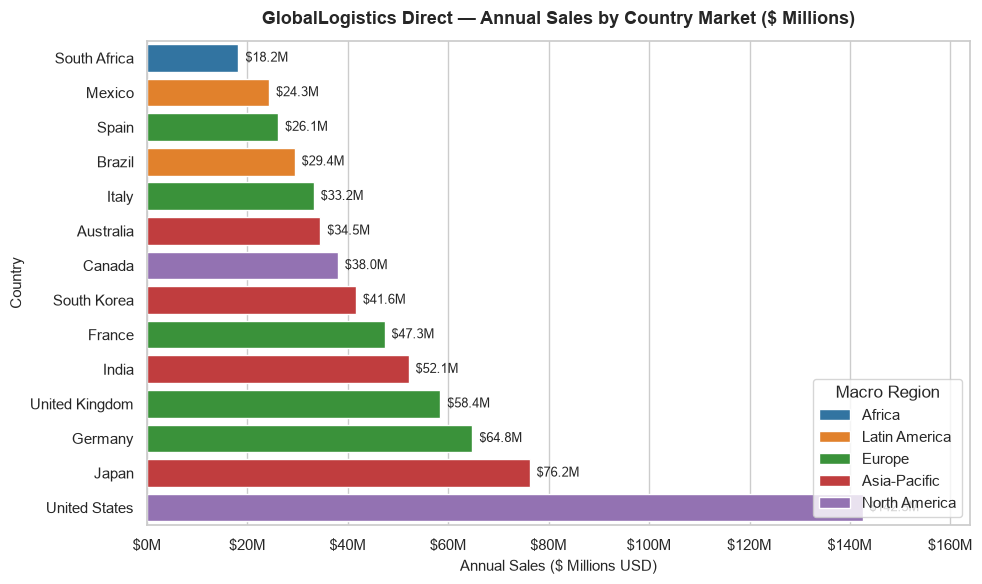

In [6]:
# Sort countries ascending for clean top-down horizontal presentation
df_sorted = df.sort_values(by="sales", ascending=True).reset_index(drop=True)

plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=df_sorted,
    x="sales",
    y="country",
    hue="region",
    palette="tab10"
)

plt.title("GlobalLogistics Direct — Annual Sales by Country Market ($ Millions)", fontsize=13, fontweight="bold", pad=12)
plt.xlabel("Annual Sales ($ Millions USD)", fontsize=11)
plt.ylabel("Country", fontsize=11)
plt.gca().xaxis.set_major_formatter('${x:,.0f}M')
plt.xlim(0, df_sorted["sales"].max() * 1.15)
plt.legend(title="Macro Region", loc="lower right")

# Add exact value labels
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f"${width:,.1f}M",
                    (width, p.get_y() + p.get_height() / 2.),
                    va='center', ha='left', fontsize=9, xytext=(5, 0),
                    textcoords='offset points')

plt.tight_layout()
plt.show()


## 7. Plotly Express Visualizations (Choropleth & Bubble Map)

Plotly Express provides world-class interactive geospatial tools:
1. **Choropleth Map (`px.choropleth`):** Shakes countries with color intensity proportional to sales.
2. **Bubble Map (`px.scatter_geo`):** Circles are positioned over each country, where circle diameter represents sales volume. Bubble maps are often preferred because bubble area scales to the metric rather than land area.


In [7]:
# Visualization 1: Interactive Global Choropleth Map
fig_map = px.choropleth(
    df,
    locations="iso_alpha",
    color="sales",
    hover_name="country",
    hover_data={"iso_alpha": False, "sales": ":$,.1fM", "region": True},
    color_continuous_scale="Viridis",
    title="<b>Global Sales Revenue by Country ($ Millions USD)</b>"
)

fig_map.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    template="plotly_white",
    coloraxis_colorbar_title="Sales ($M)"
)

fig_map.show()


In [8]:
# Visualization 2: Interactive Bubble Map (Scatter Geo)
# Bubble maps mitigate landmass bias because circle size represents sales directly
fig_bubble = px.scatter_geo(
    df,
    locations="iso_alpha",
    size="sales",
    color="region",
    hover_name="country",
    hover_data={"iso_alpha": False, "sales": ":$,.1fM"},
    size_max=35,
    title="<b>Global Sales Bubble Map (Bubble Size Proportional to Revenue)</b>"
)

fig_bubble.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="natural earth"),
    template="plotly_white",
    legend_title="Macro Region"
)

fig_bubble.show()


## 8. Interpretation

Synthesizing the map visuals with the ranking chart yields key geographic conclusions:

1. **Market Dominance (The US Anchor):**
   - The **United States** is by far the largest single national market, generating **$142.5 Million** (representing nearly 21% of worldwide revenue).

2. **The East Asian Corridor:**
   - Asia-Pacific is a massive growth engine: **Japan** ($76.2M), **India** ($52.1M), and **South Korea** ($41.6M) produce tremendous sales within a relatively concentrated geographic zone.

3. **Western European Stability:**
   - Europe demonstrates remarkable geographic density: **Germany** ($64.8M), **UK** ($58.4M), and **France** ($47.3M) form a continuous economic corridor with low shipping borders.

4. **Under-Represented Emerging Territories:**
   - **Latin America** (Brazil $29.4M, Mexico $24.3M) and **Africa** (South Africa $18.2M) exhibit significant whitespace for long-term expansion.


## 9. Key Insights & Recommended Business Actions

### What Happened?
- Over 75% of global revenue is concentrated across North America, Western Europe, and East Asia.

### Actionable Business Recommendations:
1. **Establish a Regional Hub in Frankfurt or Rotterdam:**
   - With Germany ($64.8M), UK ($58.4M), and France ($47.3M) driving over $170M in combined European sales, centralizing a distribution center in central Europe will cut inter-European delivery times from 5 days to 24 hours.
2. **Expand India and Southeast Asia Supply Chain:**
   - India ($52.1M) represents the fastest-growing emerging market in the portfolio. Increase localized inventory allocation to capture rising consumer tech demand.
3. **Evaluate Direct Local Presence in Latin America:**
   - Brazil and Mexico combined generate over $53M. Establishing localized customs clearance hubs will reduce import tariff frictions.

---

### Common Analytical Mistake to Avoid:
> **Mistake: The Geographic Landmass Fallacy**  
> Notice how Canada and Australia dominate huge geographic territory on the choropleth map, yet each generates under $40M in sales. Meanwhile, Japan generates nearly double Canada's sales despite occupying a fraction of Canada's physical area. **Never rely solely on a map without a companion bar chart** to communicate quantitative ranking!


## 10. Practice Exercises

### Exercise 1: Chart Interpretation
Based on the geographic visualizations:
1. Name the top 3 country markets in the *Asia-Pacific* region.
2. Which country represents the lowest sales volume in the European group?
3. Why does a bubble map provide a fairer visual comparison between Japan and Canada than a choropleth map?


### Exercise 2: Modify Chart Settings (3D Orthographic Globe)
In the code cell below:
- Modify the Plotly choropleth map to use a 3D rotating globe projection: `projection_type="orthographic"`.
- Use the `"Plasma"` color palette.
- Give the chart an executive title: *"Global Sales Revenue — 3D Globe Projection"*.


In [9]:
# Exercise 2: Student Code
fig_globe = px.choropleth(
    df,
    locations="iso_alpha",
    color="sales",
    hover_name="country",
    color_continuous_scale="Plasma",
    title="<b>Global Sales Revenue — 3D Globe Projection</b>"
)

fig_globe.update_layout(
    geo=dict(showframe=False, showcoastlines=True, projection_type="orthographic"),
    template="plotly_white"
)
fig_globe.show()


### Exercise 3: Answer a Business Question (Regional Aggregation)
Group the dataset by **`region`** and calculate:
1. Total regional sales ($ Millions).
2. The percentage contribution of each region to total worldwide sales.
Which region is the largest overall contributor?


In [10]:
# Exercise 3: Student Code
regional_summary = df.groupby("region", as_index=False)["sales"].sum()
total_global_sales = regional_summary["sales"].sum()
regional_summary["share_pct"] = (regional_summary["sales"] / total_global_sales) * 100
regional_summary = regional_summary.sort_values(by="sales", ascending=False).reset_index(drop=True)

print("Regional Sales Breakdown:")
print("-" * 50)
for _, row in regional_summary.iterrows():
    print(f"{row['region']:<15} | Sales: ${row['sales']:>6.1f}M | Share: {row['share_pct']:>5.1f}%")


Regional Sales Breakdown:
--------------------------------------------------
Europe          | Sales: $ 229.8M | Share:  33.5%
Asia-Pacific    | Sales: $ 204.4M | Share:  29.8%
North America   | Sales: $ 180.5M | Share:  26.3%
Latin America   | Sales: $  53.7M | Share:   7.8%
Africa          | Sales: $  18.2M | Share:   2.7%


## 11. Challenge Activity

**Per-Capita Metric Engineering:**  
Raw sales figures can mislead because populous countries naturally buy more goods.

1. Review the population estimates (in Millions) provided in the cell below.
2. Calculate **`sales_per_capita`** (Sales $ / Population):
   $$\text{Sales Per Capita} = \frac{\text{sales } \times 1,000,000}{\text{population } \times 1,000,000}$$
3. Build a Plotly bubble map where bubble size reflects `sales_per_capita`, and write two insights regarding which countries have the highest per-person purchasing density.


In [11]:
# Challenge Activity: Sales Per Capita
# Approximate population in millions for each country
population_map = {
    "USA": 335, "JPN": 125, "DEU": 84, "GBR": 67, "IND": 1420,
    "FRA": 68,  "KOR": 52,  "CAN": 40, "AUS": 26, "ITA": 59,
    "BRA": 215, "ESP": 48,  "MEX": 128,"ZAF": 60
}

df["population_m"] = df["iso_alpha"].map(population_map)
df["sales_per_capita"] = (df["sales"] * 1_000_000) / (df["population_m"] * 1_000_000)

fig_per_capita = px.scatter_geo(
    df,
    locations="iso_alpha",
    size="sales_per_capita",
    color="region",
    hover_name="country",
    hover_data={"sales_per_capita": ":$.2f", "sales": ":$,.1fM"},
    size_max=35,
    title="<b>Global Purchasing Intensity: Sales Per Capita ($ / Person)</b>"
)
fig_per_capita.update_layout(template="plotly_white", geo=dict(projection_type="natural earth"))
fig_per_capita.show()


## 12. Key Takeaways

- **Geographic Visuals Reveal Spatial Clustering:** Maps are uniquely suited for identifying geopolitical clusters, shipping corridors, and regional expansion targets.
- **Always Use Standard ISO Codes:** Standard 3-letter codes (`iso_alpha`) eliminate spelling ambiguities (e.g. "USA" vs "United States" vs "U.S.") across mapping libraries.
- **Mitigate Landmass Bias:** Remember that geographical area does not equal financial revenue. Pair every choropleth with a companion sorted horizontal bar chart or bubble map.
- **Normalize When Appropriate:** For fair international market comparisons, evaluate both absolute volume ($ Sales) and normalized market penetration ($ per Capita).
